## Project #4 -  Interpret
### Import packages and data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

In [21]:
##Install any needed pacakages with the following code, then comment the code out
#import sys
#!{sys.executable} -m pip install seaborn

### Install GeoPandas
For this project we will be using the `GeoPandas` package to help us map our NRI Risk Data.  In the space below, let's install `GeoPands`.

In [22]:
#import sys
#!{sys.executable} -m pip install geopandas

##Import
import geopandas as gpd

ModuleNotFoundError: No module named 'geopandas'

#### Load in the data for Project #4
First, let's refresh our memories and load in all of the data needed for this project.  There are  two CSV documents you need to download from Canvas and read into Python.  Load in your Household_data and Vehicle Data below.

In [24]:
#### Load in each CSV
ne_nri = pd.read_csv("NRI_Table_CensusTracts_Nebraska.csv")
ne_svi = pd.read_csv("Nebraska.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

#print(ne_nri)
#print(nri_dictionary)
#print(ne_svi)

#### Lab Activity #1
Show you have imported a state data set other than Nebraska.  Print out a feature of this dataset using one of our data checking methods to show you have correctly loaded the data.

In [25]:
#### Student import in space below
all_tracts = pd.read_csv('NRI_Table_CensusTracts.csv')
de_nri = all_tracts[all_tracts["STATE"]=='Delaware']
de_svi = pd.read_csv('Delaware.csv')

## Joining Datasets

Next, wouldn't it be nice if all this data was in one dataframe instead of 2?  We can create one big DataFrame in Python by using the `merge()` command.  `merge()` does something to the data that we call "joining" in the data science world.  Basically, you take two data files and join them using a "key" that each dataframe has in common.  If we look at our data CSVs, both CSVs have a unique code related to the city, county and FIPS number.  In the Census Tract data it is "STCOFIPS" and in the SVI data it is "STCNTY". 

Therefore our first step will be to make sure each dataframe has the same column name to merge on. 
 Then we can complete the merge.


In [26]:
### Create a column in Census Tract called "STCNTY"
ne_nri['STCNTY'] = ne_nri['STCOFIPS']
ne_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [27]:
de_nri['STCNTY'] = de_nri['STCOFIPS']
de_nri.columns

C:\Users\owens\AppData\Local\Temp\ipykernel_58840\3032711245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_nri['STCNTY'] = de_nri['STCOFIPS']


Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

Now, each dataframe has a column with a unique identifier that can be used for the join.  We can only join two dataframes at a time and there are a couple different modes for merging.

Check out this link to see more information: https://www.datacamp.com/tutorial/joining-dataframes-pandas 

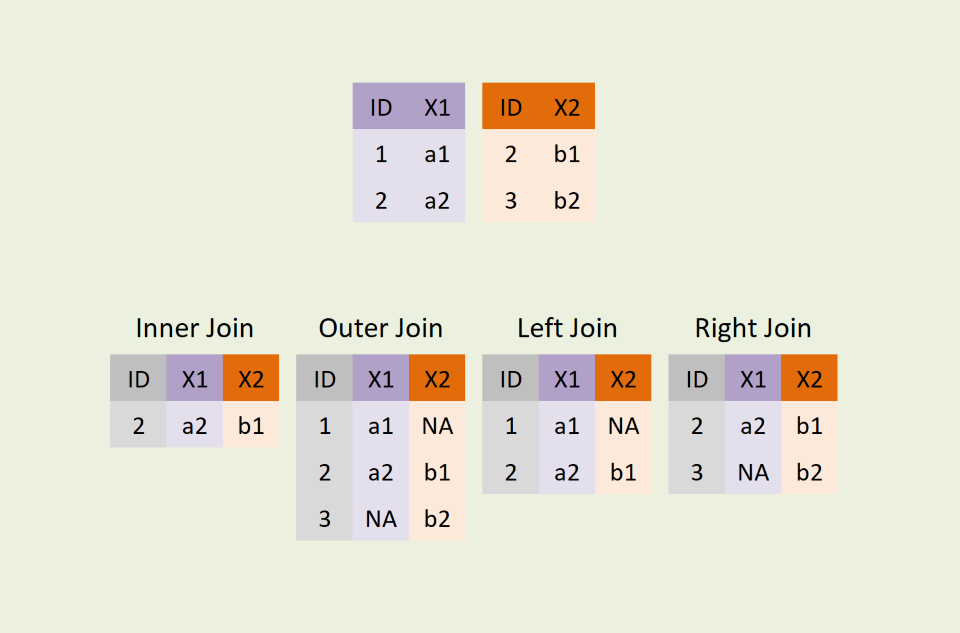

In [28]:
##The following images shows the different ways we can join data
join_png = Image.open('join_types.png')
display(join_png)

In [29]:
##Let's use merge to join our data
complete_data = pd.merge(ne_nri, ne_svi, on = 'STCNTY')


Once you've joined your data, take a look at the columns.  How many do you now have?

In [30]:
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS', 'COUNTY_x',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [31]:
complete_data = pd.merge(de_nri, de_svi, on = 'STCNTY')
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS', 'COUNTY_x',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

#### Lab Activity #2
Show you can correctly merge your state NRI data with your state SVI data

In [32]:
## Student merge of NRI and SVI data for state other than Nebraska
complete_data = pd.merge(de_nri, de_svi, on = 'STCNTY')

Wait a minute, why do we now have `STATE_x` and `STATE_y`?  this is because we merged everything in the data and Python said, well since you have two `STATE` columns and you didn't tell me to do anything special with them, I'm going to name them x and y so you don't get mad at me for dropping data.  So now from this complete data set, we either have to call `STATE_x` or `STATE_y`.  There's nothing wrong with this, you just have to make sure you understand that when you have duplicate columns, you'll have to be careful about calling specific names.

Alternatively, we can try different types of merges.  `merge()` has different forms and arguments that we can use to get rid of duplicates.  We can use the `suffixes` argument of the `merge()` function to tell Python, only keep the columns from the `right` dataframe.  When we merge, the we have a "right" dataframe and a "left" dataframe.

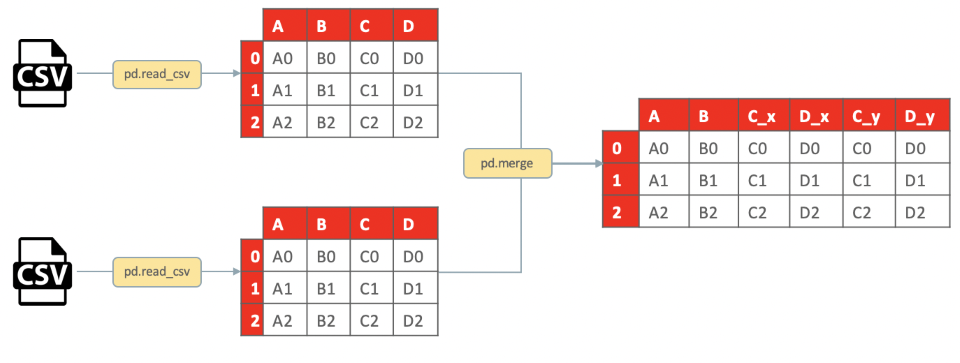

In [33]:
##This figure shows how pandas will merge two datasets if you don't supply any additional arguments to the merge function
merge_png2 = Image.open('flow_pandas_merge.png')
display(merge_png2)

Let's try to fix this `merge()` and remove extra rows.  We can use the `suffixes` argument of the `merge()` function.  The text below will remove the suffix the first time it sees a column like `STATE` and add `_right` the second time it sees `STATE`.

In [36]:
### Merge without repeat column names
complete_data = pd.merge(ne_nri, ne_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [37]:
complete_data = pd.merge(de_nri, de_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

Awesome, all set to go with our big dataset!

## Creating New Columns

Now, we know risk is a combination of factors.  This means when we look at columns in the NRI and SVI dataset, we are going to want to mulitply or combine columns line by line.  Lucky for us, Python and other coding languages are built for this.  

When we want to create a new column, we use the indexing method with `[ ]` to tell Python to add a new column to an existing dataframe.  It's always best to practice doing this, so let's try to hail events.  To get a risk score, theoretically we need to multiply a frequency times an impact.  

#### Lab Activity #3
Using the NRI data dictionary, choose a variable for frequency and a variable for impact

Frequency:

Impact:

Dr. Lane's Example: I will choose "HAIL_AFREQ" which is the annual frequency of hail events and "HAIL_EXPA" which is related to exposure and agricultural value.  

In [47]:
## Dr. Lane's Example
### Create a column called "my_risk" which multiplies your frequency by your impact
complete_data['HAIL'] = complete_data['HAIL_AFREQ']*complete_data['HAIL_EXPA']

##Use print to see if your code correctly multiples columns
print(complete_data['HAIL'], complete_data['HAIL_AFREQ'], complete_data['HAIL_EXPA'])


0        5.173903e+07
1        5.173903e+07
2        5.173903e+07
3        5.173903e+07
4        5.173903e+07
             ...     
27888    7.512385e+03
27889    7.512385e+03
27890    7.512385e+03
27891    7.512385e+03
27892    7.512385e+03
Name: HAIL, Length: 27893, dtype: float64 0        1.735867
1        1.735867
2        1.735867
3        1.735867
4        1.735867
           ...   
27888    0.534880
27889    0.534880
27890    0.534880
27891    0.534880
27892    0.534880
Name: HAIL_AFREQ, Length: 27893, dtype: float64 0        29805867.0
1        29805867.0
2        29805867.0
3        29805867.0
4        29805867.0
            ...    
27888       14045.0
27889       14045.0
27890       14045.0
27891       14045.0
27892       14045.0
Name: HAIL_EXPA, Length: 27893, dtype: float64


#### Lab Activity #4
Show you can multiply your 2 selected columns from above to get a new value for risk.  Print out the columns so you can show the math has been completed correctly.

In [48]:
### Student creation of a new risk column
complete_data['FLOOD'] = complete_data['CFLD_AFREQ']*complete_data['CFLD_EXPP']

##Use print to see if your code correctly multiples columns
print(complete_data['FLOOD'], complete_data['CFLD_AFREQ'], complete_data['CFLD_EXPP'])


0        0.582630
1        0.582630
2        0.582630
3        0.582630
4        0.582630
           ...   
27888    1.179629
27889    1.179629
27890    1.179629
27891    1.179629
27892    1.179629
Name: FLOOD, Length: 27893, dtype: float64 0        0.012
1        0.012
2        0.012
3        0.012
4        0.012
         ...  
27888    3.687
27889    3.687
27890    3.687
27891    3.687
27892    3.687
Name: CFLD_AFREQ, Length: 27893, dtype: float64 0        48.552518
1        48.552518
2        48.552518
3        48.552518
4        48.552518
           ...    
27888     0.319943
27889     0.319943
27890     0.319943
27891     0.319943
27892     0.319943
Name: CFLD_EXPP, Length: 27893, dtype: float64


In [49]:
## Student creation of a new risk column
complete_data['WINTER'] = complete_data['WNTW_AFREQ']*complete_data['WNTW_EXPP']

##Use print to see if your code correctly multiples columns
print(complete_data['WINTER'], complete_data['WNTW_AFREQ'], complete_data['WNTW_EXPP'])

0        56595.000000
1        56595.000000
2        56595.000000
3        56595.000000
4        56595.000000
             ...     
27888        5.923921
27889        5.923921
27890        5.923921
27891        5.923921
27892        5.923921
Name: WINTER, Length: 27893, dtype: float64 0        7.736842
1        7.736842
2        7.736842
3        7.736842
4        7.736842
           ...   
27888    5.923921
27889    5.923921
27890    5.923921
27891    5.923921
27892    5.923921
Name: WNTW_AFREQ, Length: 27893, dtype: float64 0        7315.0
1        7315.0
2        7315.0
3        7315.0
4        7315.0
          ...  
27888       1.0
27889       1.0
27890       1.0
27891       1.0
27892       1.0
Name: WNTW_EXPP, Length: 27893, dtype: float64


### Practice Creating Columns for Project #4
####  Lab Activity #5:

With your Project #4 group, choose 2 different natural hazards you would like to focus on.  Create 3 new columns in your data by multiplying or dividing columns.  If you use your time wisely, these could maybe be used in your Project #4 analysis!

In [50]:
##Example from Dr. Lane

### Create a column that multiplies Landslide annual frequency by building value loss
complete_data['landslide_building_risk'] = complete_data['LNDS_AFREQ']*complete_data['LNDS_EALB']

#print(complete_data)

#### Complete your Lab Activity #5 in the space below

Identify 2 Hazards:
1. Hazard #1: caostal flooding
2. Hazard #2: winter weather

Create 3 new columns:
1. Column #1:
2. Column #2:
3. Column #3:


In [51]:
### Student code that creates 3 new columns in the joined dataset
complete_data['hail_building_risk'] = complete_data['HAIL_AFREQ']*complete_data['HAIL_EALB']
complete_data['flood_building_risk'] = complete_data['CFLD_AFREQ']*complete_data['CFLD_EALB']
complete_data['winter_building_risk'] = complete_data['WNTW_AFREQ']*complete_data['WNTW_EALB']

## Aggregate Data for Plotting and Reporting

Now the data we have created is great, but how do we present it to our client?  Well, what about all those filtering, grouping and aggregating skills we learned in Project #1?  Let's see if we can find a way to organize our data so it becomes plottable.

Let's first try grouping by county.  Now I have two columns, one for Hail damage to agriculture and Landslide damage to buildings.  That's probably not the best comparison, but it is a comparison so let's use it as an example.  Our end goal is: a grouped bar plot by county.

In [54]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(mean_hail_risk=('hail_building_risk', 'mean'),
                                                   mean_flood_risk=('flood_building_risk', 'mean'),
                                                   mean_winter_risk=('winter_building_risk', 'mean'))

print(grouped_data)

            mean_hail_risk  mean_flood_risk  mean_winter_risk
COUNTY                                                       
Kent            335.593311     99631.933229      25388.206988
New Castle      479.041502     94314.955546      46471.424996
Sussex          316.908513    697658.105300      25914.715847


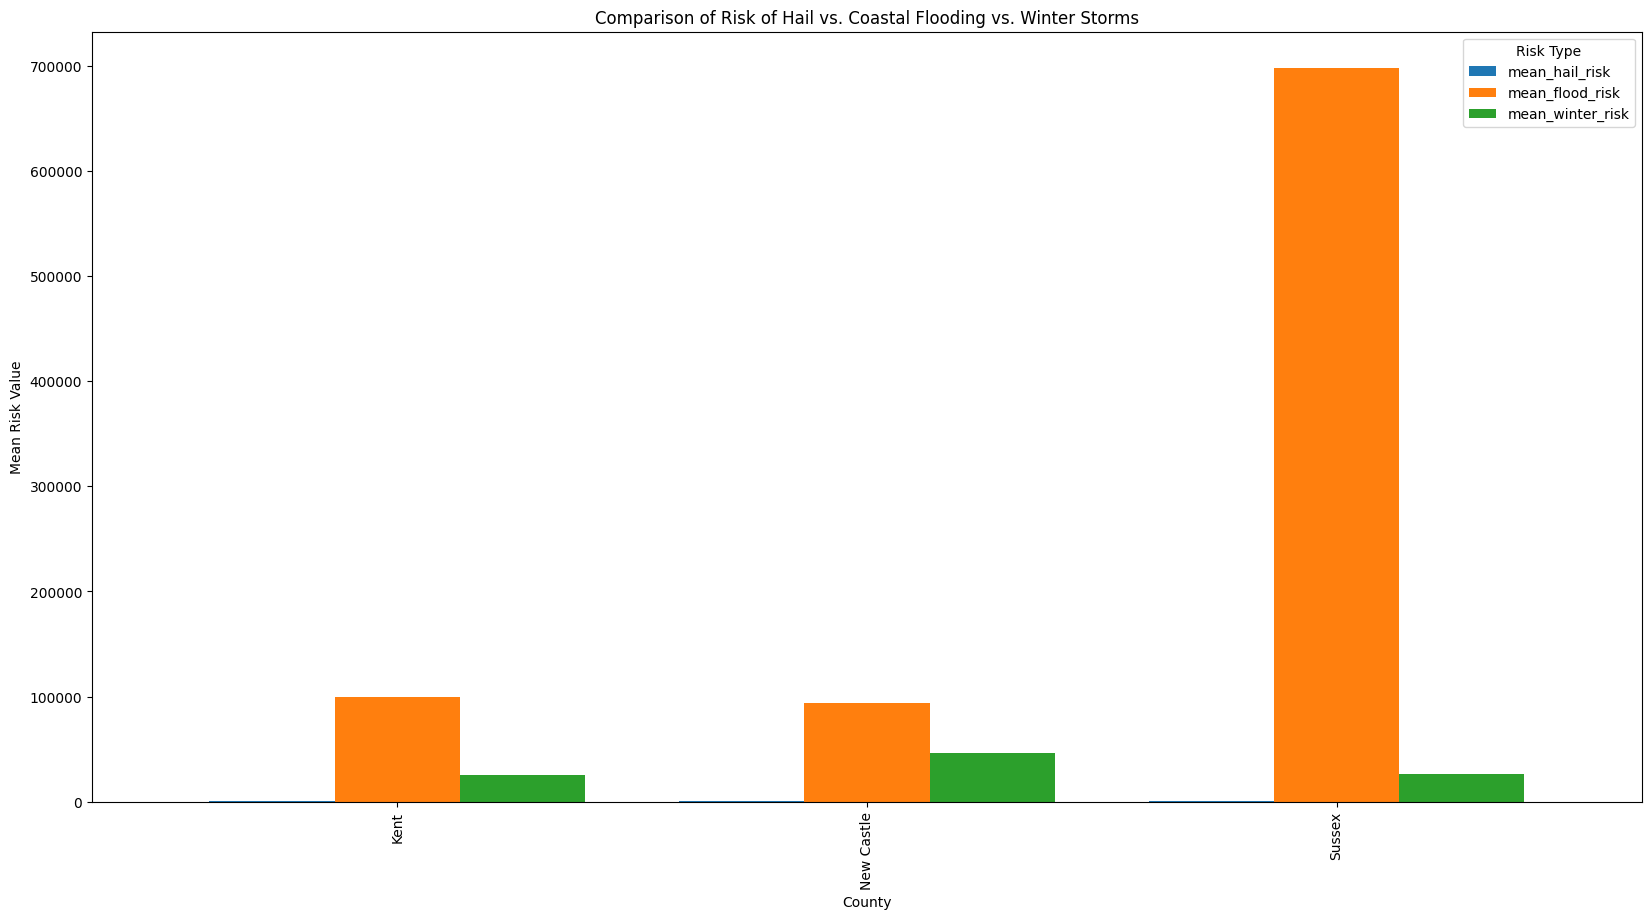

In [55]:
# Create bar plot with side-by-side bars (dodged effect)
grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Risk of Hail vs. Coastal Flooding vs. Winter Storms')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()